Homework 2 for the MSE510/420 Course
- Instructor Sergei V. Kalinin, sergei2@utk.edu
- Please provide your name in the beginning of the notebook
- To submit the homework, please share it with my gmail address (available on Canvas)


Problem 1: Making function
- define an (arbitrary) scalar function  
- plot a graph over a chosen range
- create an array of sampled points (e.g. 7)
- show the points on the graph

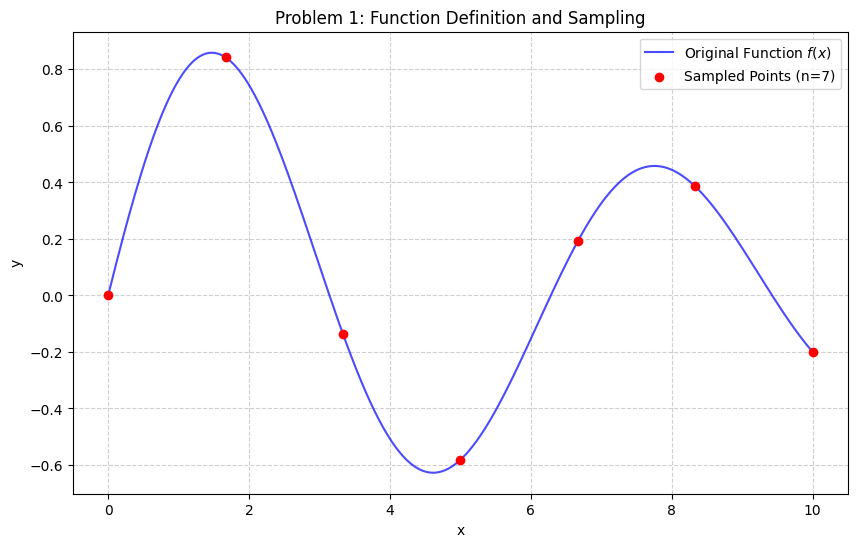

Sampled x values: [ 0.          1.66666667  3.33333333  5.          6.66666667  8.33333333
 10.        ]
Sampled y values: [ 0.          0.84259465 -0.13654791 -0.58161697  0.19209565  0.38561643
 -0.20013418]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a scalar function
def my_function(x):
    return np.sin(x) * np.exp(-0.1 * x)

# 2. Plot a graph over a chosen range
x_range = np.linspace(0, 10, 500)
y_range = my_function(x_range)

# 3.Array of sampled points (7 points)
x_samples = np.linspace(0, 10, 7)
y_samples = my_function(x_samples)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='Original Function $f(x)$', color='blue', alpha=0.7)
plt.scatter(x_samples, y_samples, color='red', label='Sampled Points (n=7)', zorder=5)

plt.title('Problem 1: Function Definition and Sampling')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("Sampled x values:", x_samples)
print("Sampled y values:", y_samples)




Problem 2: Spline interpolation
- Interpolate the function using spline method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

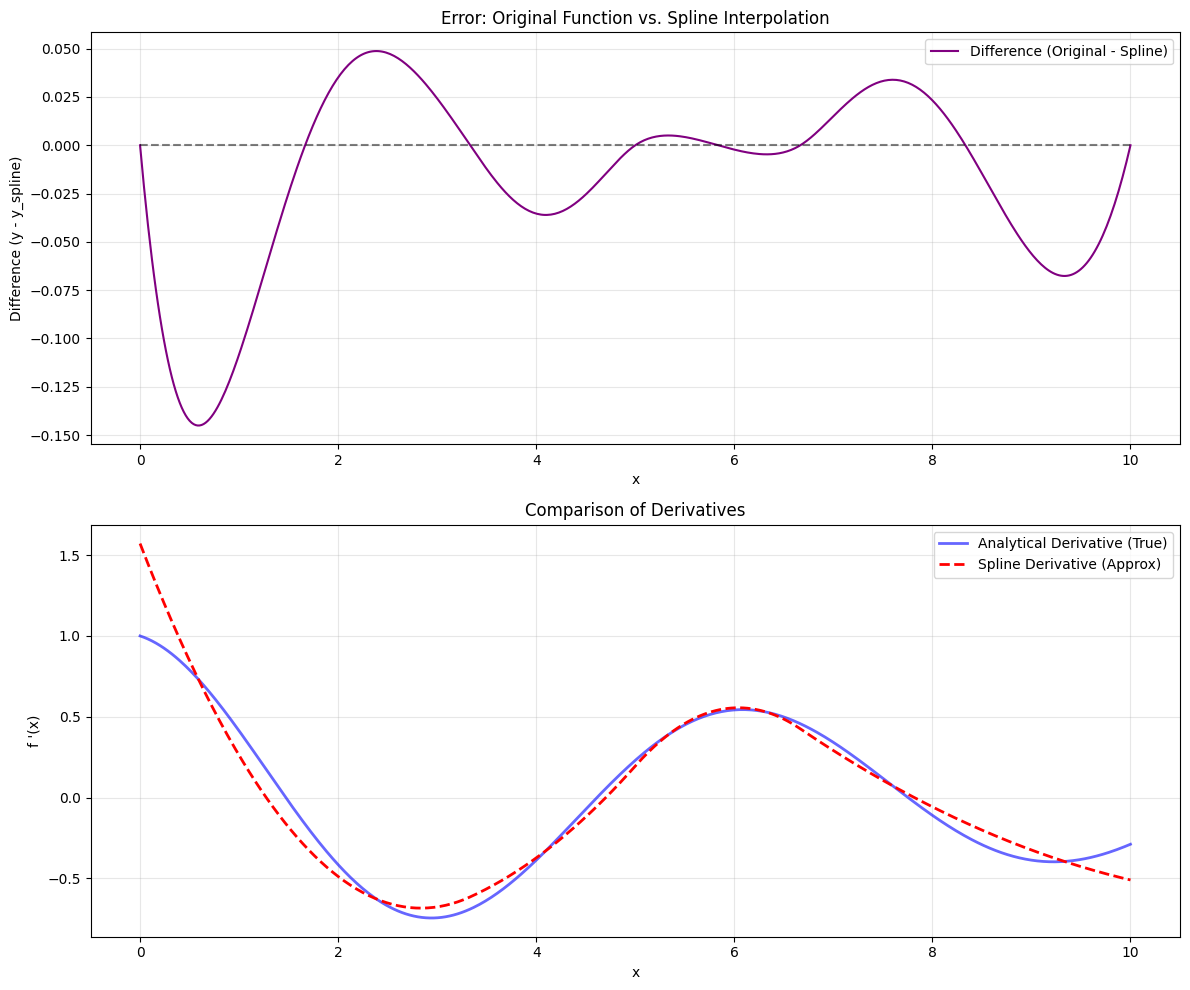

In [ ]:
from scipy.interpolate import CubicSpline

cs = CubicSpline(x_samples, y_samples)
y_spline = cs(x_range)

# 2. Plot the difference (Error)
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(x_range, y_range - y_spline, color='purple', label='Difference (Original - Spline)')
plt.hlines(0, 0, 10, colors='black', linestyles='dashed', alpha=0.5) # Zero line for reference
plt.title('Error: Original Function vs. Spline Interpolation')
plt.xlabel('x')
plt.ylabel('Difference (y - y_spline)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Differentiate the Original Function (Analytically)
# Rule: d/dx [sin(x) * e^(-0.1x)] = cos(x)e^(-0.1x) + sin(x)(-0.1)e^(-0.1x)
def analytical_derivative(x):
    return np.exp(-0.1 * x) * (np.cos(x) - 0.1 * np.sin(x))

y_deriv_true = analytical_derivative(x_range)

# 4. Differentiate the Interpolated Function
# The CubicSpline object can calculate its own derivative automatically
y_deriv_spline = cs(x_range, nu=1) # nu=1 requests the 1st derivative

# 5. Compare the results (Plotting Derivatives)
plt.subplot(2, 1, 2)
plt.plot(x_range, y_deriv_true, label='Analytical Derivative (True)', color='blue', alpha=0.6, linewidth=2)
plt.plot(x_range, y_deriv_spline, label='Spline Derivative (Approx)', color='red', linestyle='--', linewidth=2)
plt.title('Comparison of Derivatives')
plt.xlabel('x')
plt.ylabel("f '(x)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Problem 3: Linear interpolation
- Interpolate the function using linear method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

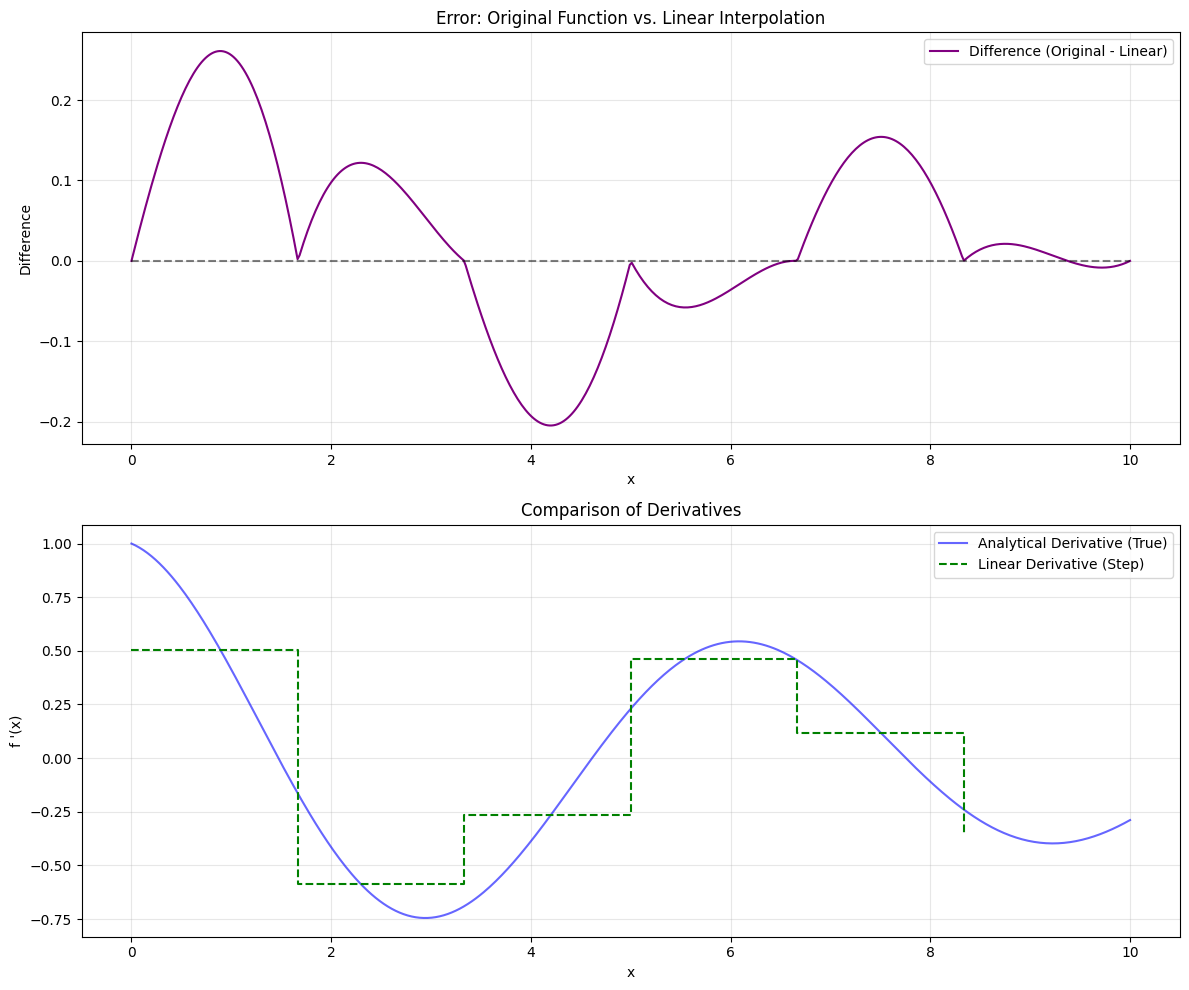

In [ ]:
from scipy.interpolate import interp1d

# 1. Interpolate the function using linear method
linear_func = interp1d(x_samples, y_samples, kind='linear')
y_linear = linear_func(x_range)

# 2. Plot the difference between original and interpolated function
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
# Calculate the error: True values - Linear approximation
error = y_range - y_linear
plt.plot(x_range, error, color='purple', label='Difference (Original - Linear)')
plt.hlines(0, 0, 10, colors='black', linestyles='dashed', alpha=0.5)
plt.title('Error: Original Function vs. Linear Interpolation')
plt.xlabel('x')
plt.ylabel('Difference')
plt.legend()
plt.grid(True, alpha=0.3)

# 3 & 4. Differentiate the function (Analytically vs Interpolated)
# Analytical derivative (True) from Problem 2
y_deriv_true = analytical_derivative(x_range)

# Derivative of the Linear Interpolated Function
# The derivative of a line segment is just its slope (rise over run).
slopes = np.diff(y_samples) / np.diff(x_samples)

# 5. Compare the results
plt.subplot(2, 1, 2)
plt.plot(x_range, y_deriv_true, label='Analytical Derivative (True)', color='blue', alpha=0.6)

# Plot the slopes as a step function (post) because the slope is constant between two sample points
plt.step(x_samples[:-1], slopes, where='post', label='Linear Derivative (Step)', color='green', linestyle='--')

plt.title('Comparison of Derivatives')
plt.xlabel('x')
plt.ylabel("f '(x)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Problem 4: Lagrange polynomial interpolation
- Interpolate the function using Lagrange polynomial method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

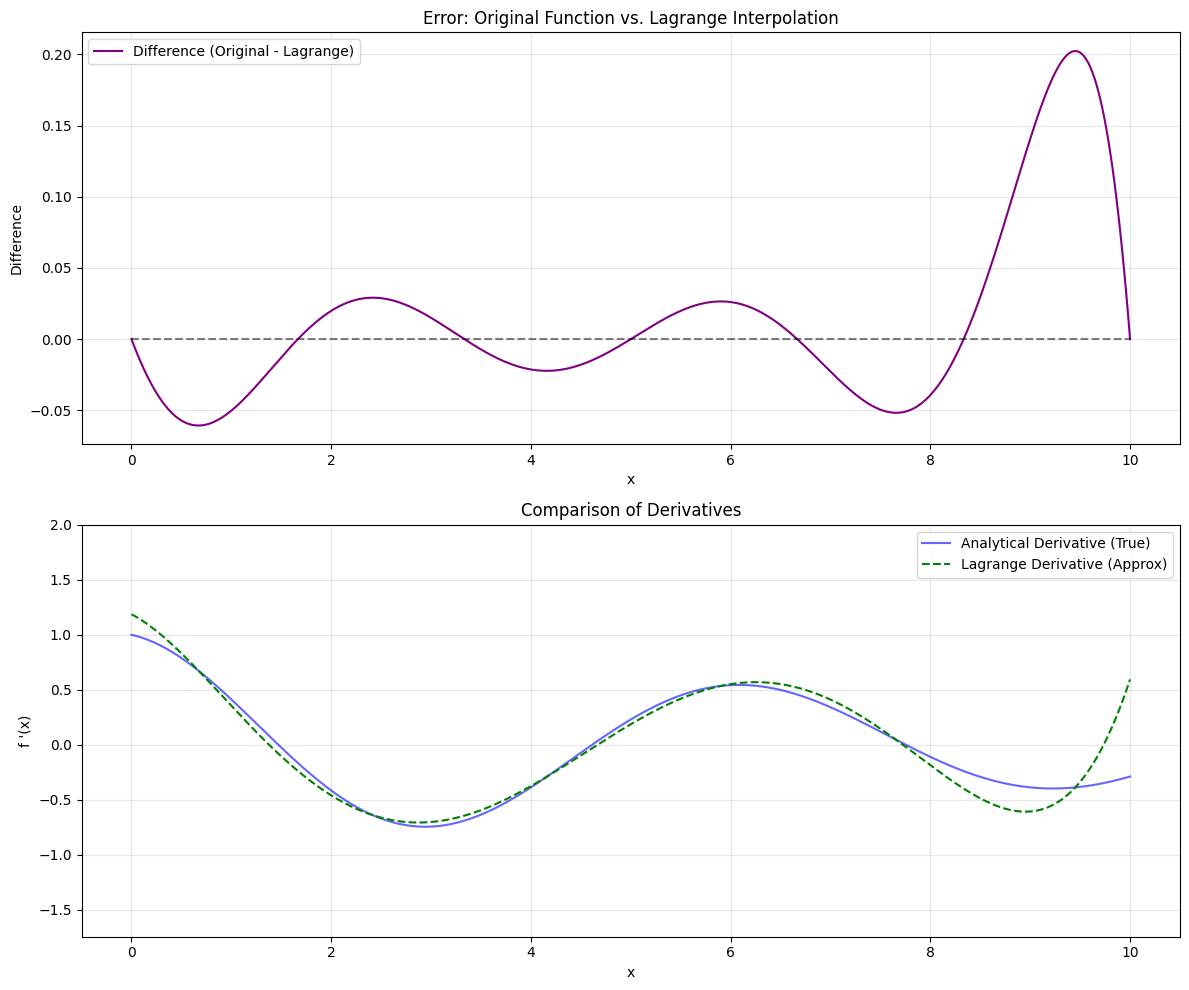

The Lagrange Polynomial is:
           6            5           4          3         2
0.0003173 x - 0.008458 x + 0.07466 x - 0.2066 x - 0.235 x + 1.187 x


In [ ]:
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial

# 1. Interpolate using Lagrange polynomial method
# scipy.interpolate.lagrange returns a numpy poly1d object (the polynomial equation)
lagrange_poly = lagrange(x_samples, y_samples)
y_lagrange = lagrange_poly(x_range)

# 2. Plot the difference (Error)
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
error_lagrange = y_range - y_lagrange
plt.plot(x_range, error_lagrange, color='purple', label='Difference (Original - Lagrange)')
plt.hlines(0, 0, 10, colors='black', linestyles='dashed', alpha=0.5)
plt.title('Error: Original Function vs. Lagrange Interpolation')
plt.xlabel('x')
plt.ylabel('Difference')
plt.legend()
plt.grid(True, alpha=0.3)

# 3 & 4. Differentiate the interpolated function
# The lagrange_poly object is a standard numpy polynomial, so it has a .deriv() method
lagrange_derivative_poly = lagrange_poly.deriv()
y_deriv_lagrange = lagrange_derivative_poly(x_range)

# Analytical derivative (True) from Problem 2
y_deriv_true = analytical_derivative(x_range)

# 5. Compare the results
plt.subplot(2, 1, 2)
plt.plot(x_range, y_deriv_true, label='Analytical Derivative (True)', color='blue', alpha=0.6)
plt.plot(x_range, y_deriv_lagrange, label='Lagrange Derivative (Approx)', color='green', linestyle='--')

plt.title('Comparison of Derivatives')
plt.xlabel('x')
plt.ylabel("f '(x)")
# Limit y-axis if the Lagrange polynomial oscillates wildly at the edges
plt.ylim(min(y_deriv_true)-1, max(y_deriv_true)+1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Print the actual polynomial equation
print("The Lagrange Polynomial is:")
print(lagrange_poly)

Problem 5:
Compare spline, linear, and Lagrange methods in terms of:
- how well they reproduce the function
- how well they reproduce the derivative
- how computationally expensive we expect them to be
- how can spline method be improved?

**1. Reproducing the function:**

  

*   Linear: reliable but crude, it misses all curvature between points
*   Lagrange: good in the center but suffers from Runge's phenomenon at the edges

*   Spline: best performance since it produces a smooth curve without oscillation

2. Reproducing the derivative:



*   Linear: Poor, result is a jagged "step function" (discontinuous).
*   Lagrange: Unreliable. Often produces massive errors at the boundaries due to polynomial wiggling


*   Spline: great producing a smooth derivative that tracks the true rate of change

3. Computational Expense:



*   Linear: probably the lowest
*   Lagrange: highest probably since it numerically is unstable for large datasets
*   Spline: moderate since it involves solving a tridiagonal matrix system

4. Spline method improved?

I would say adding more data points focusing in the regions with high curvature and use clamped splines instead of the default mode to reduce edge error.















Problem 6: Integration
- Integrate the original and (one of the) interpolated functions
- Compare the answers

True Integral (Original):   1.315535
Spline Integral (Approx):   1.485262
Absolute Error:             0.169727


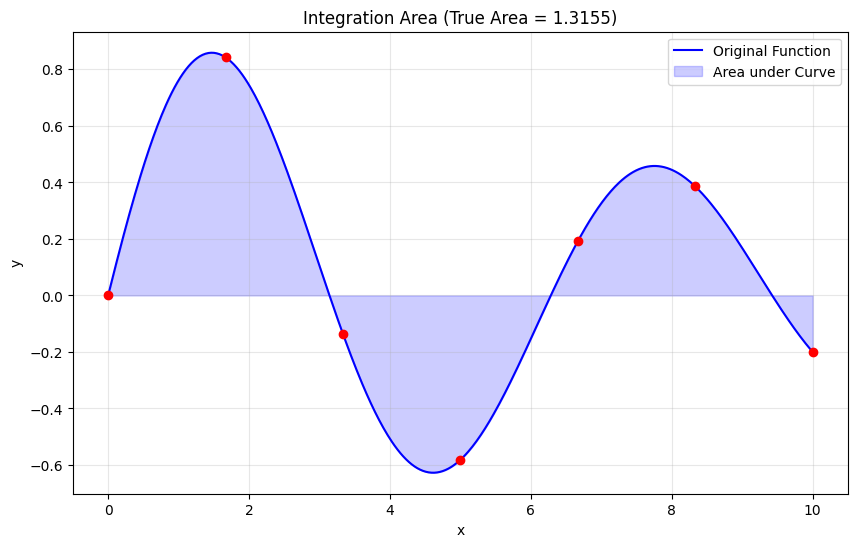

In [ ]:
from scipy.integrate import quad

# 1. Integrate the Original Function (True Value)
# We use 'quad' which is the standard tool for integrating a function defined by code
# Arguments: function name, start limit (0), end limit (10)
integral_true, error_estimate = quad(my_function, 0, 10)

# 2. Integrate the Interpolated Function (Spline)
# The CubicSpline object 'cs' from Problem 2 has a built-in .integrate method.
# This calculates the exact area under the cubic polynomial pieces.
integral_spline = cs.integrate(0, 10)

# 3. Compare the answers (I am doing only the spline)
print(f"True Integral (Original):   {integral_true:.6f}")
print(f"Spline Integral (Approx):   {integral_spline:.6f}")
print(f"Absolute Error:             {abs(integral_true - integral_spline):.6f}")

# Optional: Visualize the filled area
plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='Original Function', color='blue')
plt.fill_between(x_range, y_range, alpha=0.2, color='blue', label='Area under Curve')
plt.scatter(x_samples, y_samples, color='red', zorder=5)
plt.title(f'Integration Area (True Area = {integral_true:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Problem 7. Finding  roots:
- Find the root of the equation y = (2 * x + 3) * np.exp(-x) + np.log(x)-1.7 on the interval [0.1, 10]
- Do you expect there will be roots for x > 10? Why?

Finding all three roots:
------------------------------
Root 1 (in [0.1, 1]): x = 0.461982
Root 2 (in [1, 4]): x = 1.699085
Root 3 (in [4, 10]): x = 5.023539


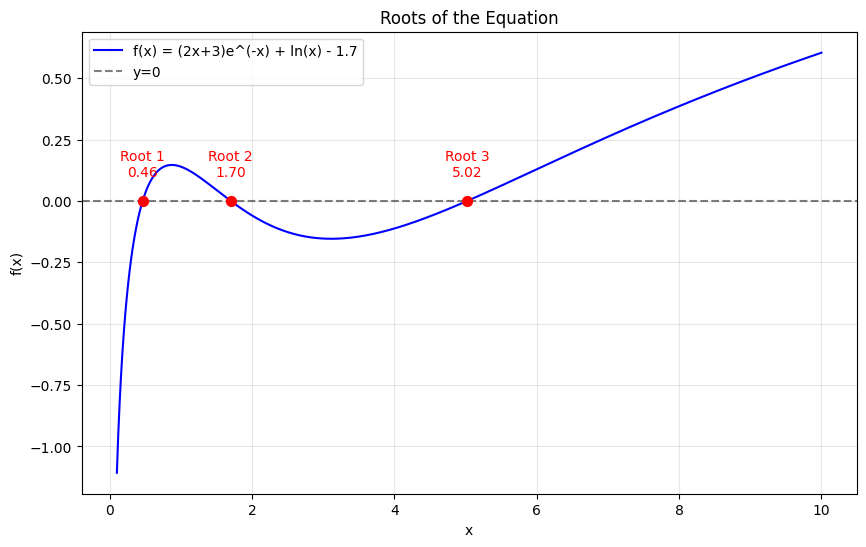

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# 1. Define the equation
def equation_to_solve(x):
    return (2 * x + 3) * np.exp(-x) + np.log(x) - 1.7

# 2. Define specific intervals where we know roots exist
intervals = [(0.1, 1), (1, 4), (4, 10)]
roots = []

print("Finding all three roots:")
print("-" * 30)

# Calculate roots
for i, (a, b) in enumerate(intervals):
    try:
        r = brentq(equation_to_solve, a, b)
        roots.append(r)
        print(f"Root {i+1} (in [{a}, {b}]): x = {r:.6f}")
    except ValueError:
        print(f"No root found in [{a}, {b}]")

# 3. Visualization
x_plot = np.linspace(0.1, 10, 500)
y_plot = equation_to_solve(x_plot)

plt.figure(figsize=(10, 6))

# Plot the function
plt.plot(x_plot, y_plot, label='f(x) = (2x+3)e^(-x) + ln(x) - 1.7', color='blue')

# Plot the zero line
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='y=0')

# Plot the roots
for i, r in enumerate(roots):
    plt.scatter(r, equation_to_solve(r), color='red', zorder=5, s=50)
    plt.text(r, 0.1, f'Root {i+1}\n{r:.2f}', horizontalalignment='center', color='red')

plt.title('Roots of the Equation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Note that for the subsequent 3 problems the answers can be correct and non-unique. So the important thing is to explain your logic.

Problem 8. Consider a ternary phase diagram of the system AxByC1-x-y as a function of (x,y,T,P), where T is temperature and P is pressure
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be indicator function indicating the presence of some phase, or weight fraction of some phase, oe even mechanical or electric properties of th esystem
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 8:

Dimensionality is 4 dimensions (2 composition x and y where the third is dependant and T & P

It is space differentiable since these are continuous physical variables

I would say density

- It is not continuous usually, when changing a phase change the density would jump instantly representing a discontunuity in the function
- It is not differentiable since if the function is discontinuous, it cannot be differentiable at that point
- I would say you can do interpolation but when the phase boundary arises such one point is solid and the next one is liquid, the interpolation method would try to smooth out the jump creating the Gibbs phenomenon
- It can be integrated even if the density jumps at the phase boundary


Problem 9. Consider charging of the battery, where charging is induced by applying bias over time, V(t).
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be state of charge after charging or state of health. Or probability of thermal runaway.
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 9:

Parameter space: 1 (time V(t))
- It is differentiable, time is a continous parameter
- State of Charge
- The answer is continous, the function will be a connected line without any jumps
- The function is differentiable (Current I = dQ/dt), since the current flows into the battery

- It can be interpolated because the battert behaves smoothly and you can mathematically get an approximation for the battery %
- It can be integrated since integration just sum up values over time


Problem 10. Consider the chemical space of small molecules, https://en.wikipedia.org/wiki/Chemical_space .
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be anything from molecular weight to enthalpy of formation, HOMO-LUMO gap, etc/
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 10:

Dimensionality is discrete really high since the number of all possible small molecules defined by their arrangement can be more than 10^31

- It is not differentiable since in chemical space, you jump from one molecule to another

- HOMO-LUP Gap
- It is not continous since the input is discrete, so the energy output is a set of discrete points
- It is not differentiable since it is not continuous
- It is hard to interpolate between two molecules since you do not have a middle point, but I guess here is where ML can help
